# Malignant classification from SwiftCNV output

This notebook demostrates how to identify malignant cells from the CNV matrix generated by swiftCNV and shows different functions on how to explore the results. It uses the classification logic described in [SherlockCell](https://github.com/Computational-Immunogenomics/SherlockCell/wiki), the complete pipeline for malignant cell classification.

In [1]:
# !pip install /home/adrianparrilla@vhio.org/SwiftCNV --force-reinstall --no-deps

In [2]:
import os
import sys
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import logging
import requests

import swiftcnv as cnv
from swiftcnv.datasets import Qian2020_Ovarian

logging.basicConfig(level=logging.INFO, datefmt='%H:%M:%S',
                    format='%(asctime)s [%(levelname)s]: %(message)s')

warnings.simplefilter('ignore')

sc.settings.set_figure_params(figsize=(4, 4))
sns.set_style("white")

We will first run SwiftCNV on the example dataset following the first tutorial.

In [3]:
gtf_filename = 'gencode.v44.basic.annotation.gtf.gz'
output_dir = 'example_output'

adata = Qian2020_Ovarian()
print(adata)

AnnData object with n_obs × n_vars = 4000 × 12000
    obs: 'sample', 'cell_type'
    obsm: 'X_umap'


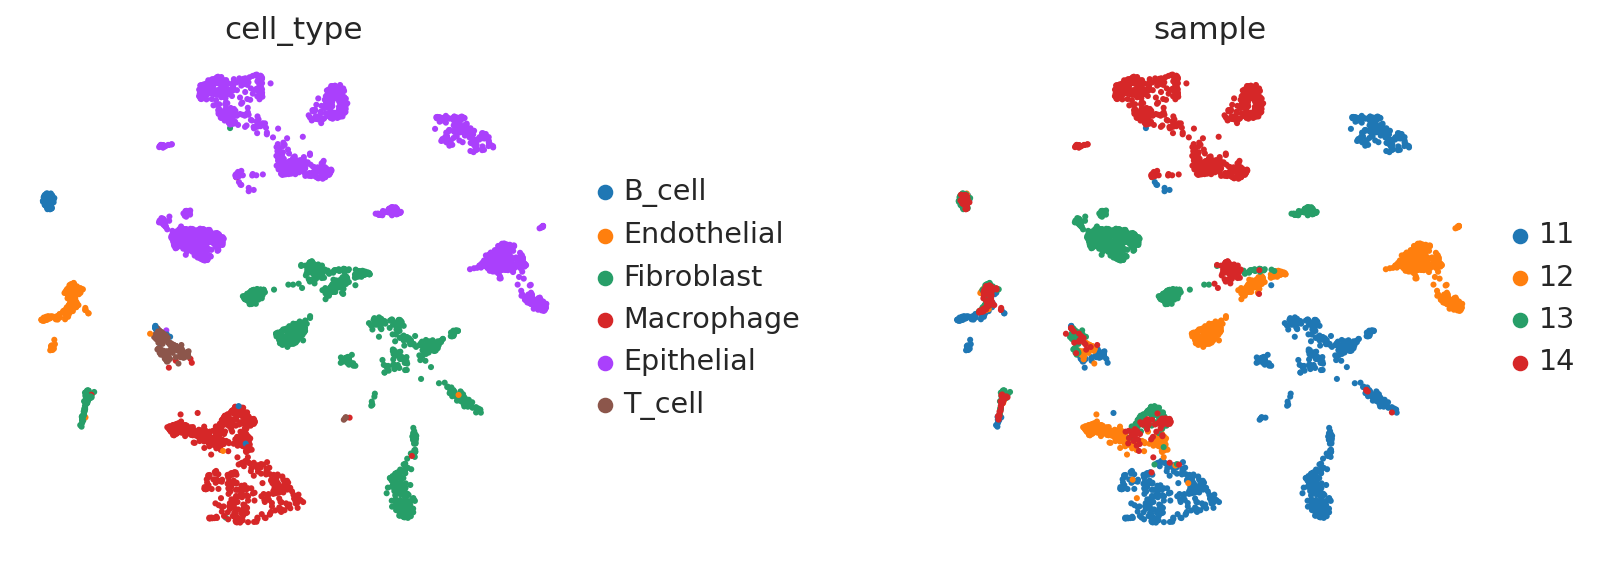

In [4]:
sc.pl.umap(adata, color=['cell_type', 'sample'], wspace=0.5, frameon=False)

In [5]:
if os.path.exists(gtf_filename):
    print(f"File '{gtf_filename}' already exists. Skipping download.")
else:
    print('Downloading file...')
    with requests.get(gtf_url, stream=True) as r:
        r.raise_for_status()
        with open(gtf_filename, 'wb') as f:
            for chunk in r.iter_content(chunk_size=8192): 
                f.write(chunk)
    print('Download finished!')

File 'gencode.v44.basic.annotation.gtf.gz' already exists. Skipping download.


For speed we will skip HMM analysis and plotting.

In [6]:
adata = cnv.run_from_adata(
    adata,
    output_dir=output_dir,
    gtf_file=gtf_filename,
    reference_col='cell_type',
    reference_vals=['T_cell', 'Macrophage', 'Fibroblast', 'Endothelial', 'B_cell'],
    sample_col='sample',
    exclude_immune=True,
    read_X=True,
    plot=False,
    run_hmm=False,
    cutoff=0.1
)

15:46:42 [INFO]: [1/4] Using pre-loaded adata...
15:46:42 [INFO]:     counts shape (cells x genes): (4000, 12000)
15:46:42 [INFO]: [2/4] Getting reference cells...
15:46:42 [INFO]:     Getting reference cells from adata.obs["cell_type"] (values=['T_cell', 'Macrophage', 'Fibroblast', 'Endothelial', 'B_cell'])
15:46:42 [INFO]:     Total cells: 4000
15:46:42 [INFO]:     Reference cells: 2371
15:46:42 [INFO]:     Observation cells: 1629
15:46:42 [INFO]:     Using sample_col: "sample" with 4 samples
15:46:42 [INFO]: [3/4] Getting gene order...
15:46:42 [INFO]:     Getting gene_order from GTF: gencode.v44.basic.annotation.gtf.gz
15:46:45 [INFO]:     Gene order from GTF: 57148 genes loaded.
15:46:45 [INFO]:     Subsetting to common genes: 11389
15:46:45 [INFO]: [4/4] Running SwiftCNV...
15:46:45 [INFO]:     SwiftCNV object created: 4000 cells x 11389 genes (2371 reference + 1629 observation cells)
15:46:45 [INFO]: === Starting SwiftCNV pipeline ===
15:46:46 [INFO]:     1: Gene filtering (min_

Now we smooth the CNV matrix by chromosome arm.

In [7]:
cnv.summarise_by_var(adata, obsm_key='cnv_mat', by='chr_arm', key_added='cnv_mat_arms', inplace=True)
adata.obsm['cnv_mat_arms'].shape

(4000, 39)

## Running Malignant Classification

For the classification, we have to specify what kind of samples we have (either `'Normal'` or `'Tumor'`). In our case, all the samples are from tumor biopsies.

In [8]:
adata.obs['sample_type'] = 'Tumor'

In [9]:
classifier = cnv.MalignantClassifier(adata, 
                                    sample_key= 'sample', 
                                    cell_type_key= 'cell_type', 
                                    cell_of_origin= "Epithelial", 
                                    sample_type_key= 'sample_type', 
                                    outdir=output_dir)

Enabling `report= True` will generate a pdf with the classification report for each sample in the specified output directory. As mentioned above, the classification steps and the logic behind are explained [here](https://github.com/Computational-Immunogenomics/SherlockCell/wiki).

In [10]:
adata = classifier.run_classification(n_jobs=3, embedding_key='X_umap', report=True, verbose=True)

15:46:50 [INFO]: >> Starting malignant classification...
15:46:50 [INFO]: Calculating scores across 4 samples.
15:46:50 [INFO]: Using 3 parallel processes.
15:46:50 [INFO]: (11) Sample type: tumor
15:46:50 [INFO]: (11) N. infercnv query cells: 156
15:46:50 [INFO]: (11) N. infercnv reference cells: 844
15:46:50 [INFO]: (12) Sample type: tumor
15:46:50 [INFO]: (13) Sample type: tumor
15:46:50 [INFO]: (13) N. infercnv query cells: 438
15:46:50 [INFO]: (12) N. infercnv query cells: 350
15:46:50 [INFO]: (13) N. infercnv reference cells: 562
15:46:50 [INFO]: (12) N. infercnv reference cells: 650
15:46:50 [INFO]: (12) Nº hotspotarms: 7
15:46:50 [INFO]: (13) Nº hotspotarms: 13
15:46:50 [INFO]: (11) Nº hotspotarms: 23
15:46:50 [INFO]: (12) Computing tumor correlation using 7 arms.
15:46:50 [INFO]: (13) Computing tumor correlation using 13 arms.
15:46:50 [INFO]: (11) Computing tumor correlation using 23 arms.
15:46:50 [WARNING]: Warning: could not find two distinct valid peaks in (12). Returning

## Plotting classification results

The classifier calculates 3 independent malignancy scores from the CNV matrix to create a CNV-based classification. The distribution of these scores can be visualised with the `plot_CNV_density` function.

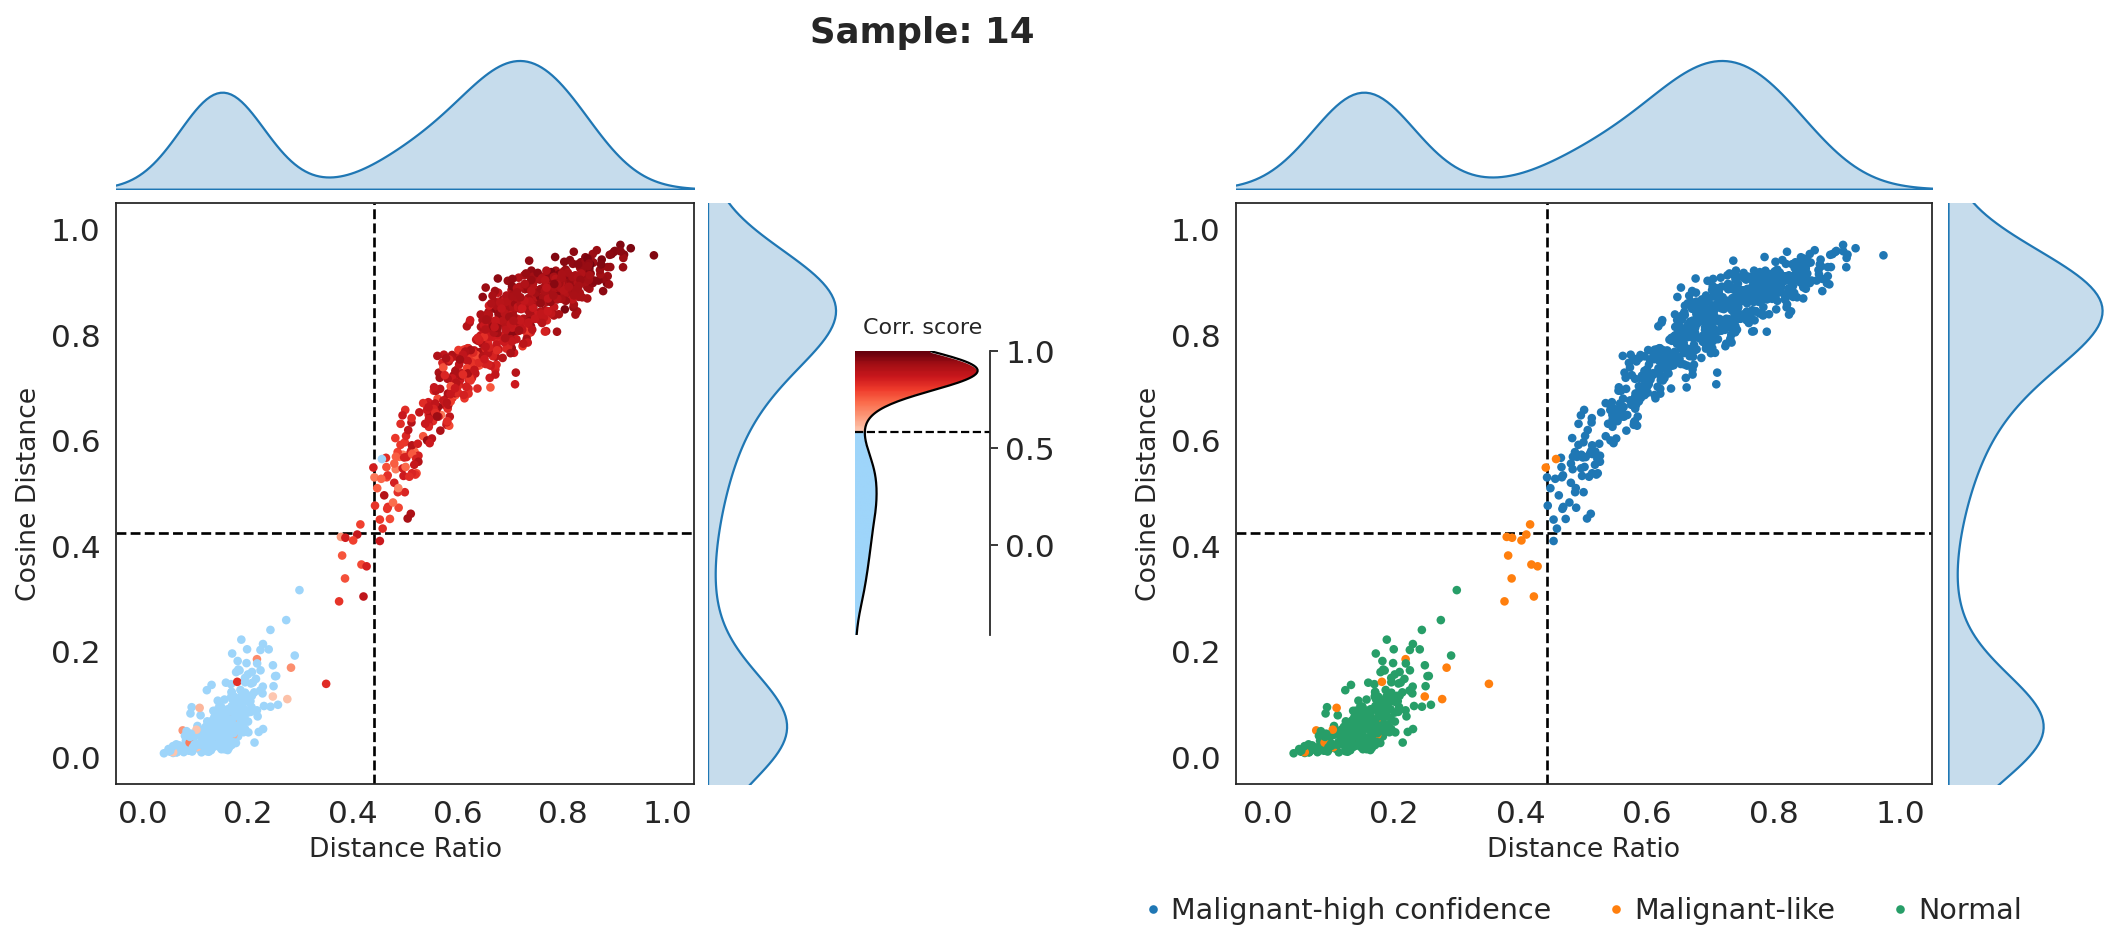

In [11]:
cnv.plot_CNV_density(adata, sample_key='sample', sample_name='14')

This initial classification is further refined with a KNN and a density based algorithm. The results at each step can be shown in the UMAP plot. 

... storing 'sample_type' as categorical


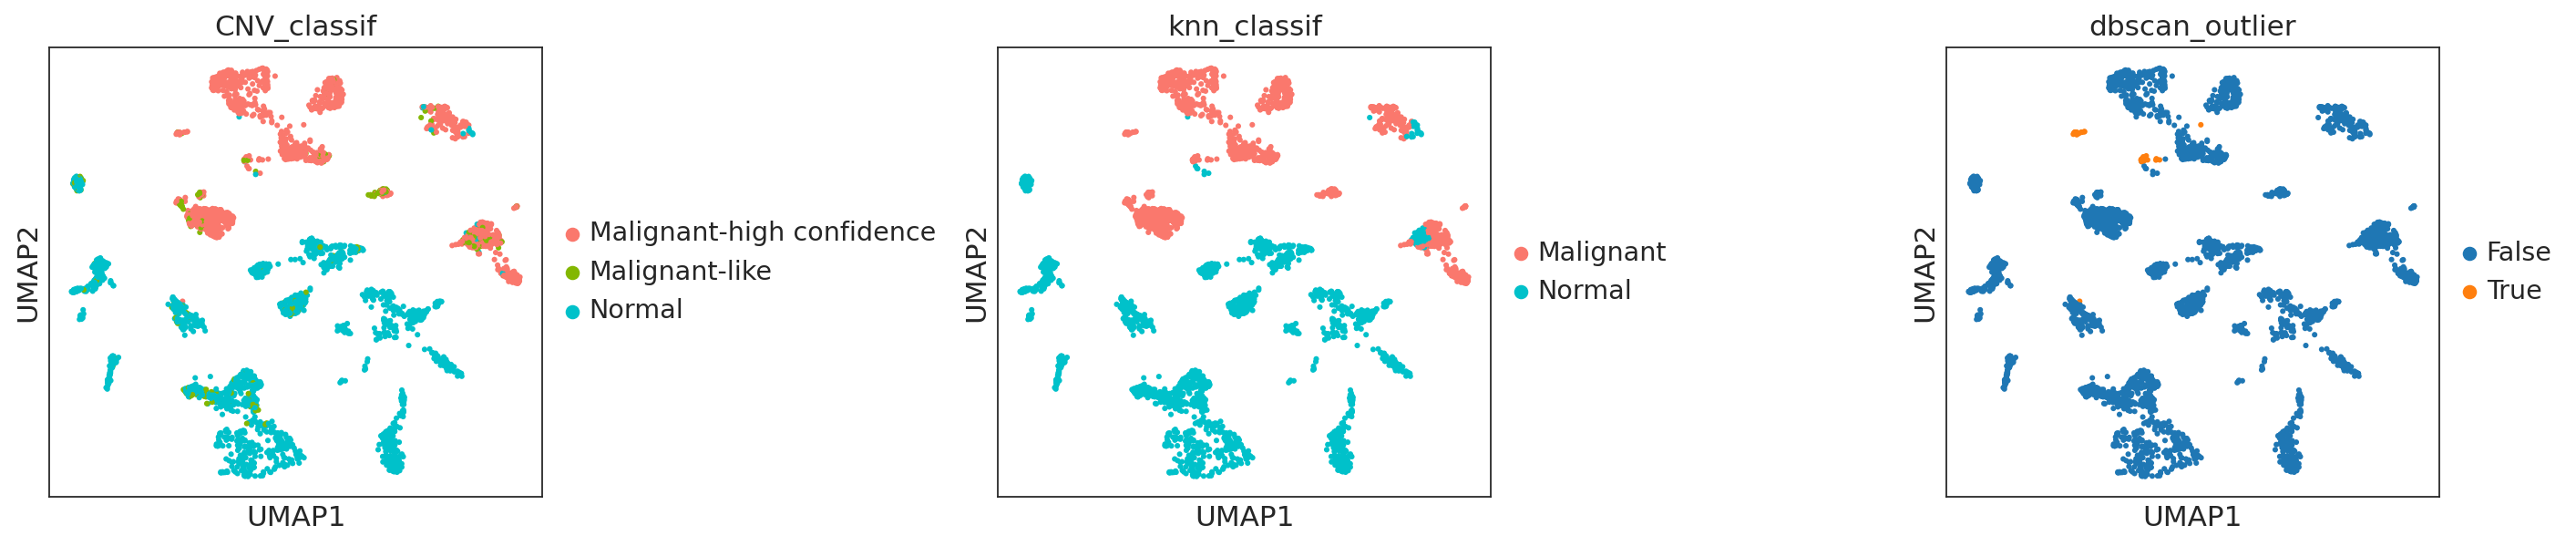

In [12]:
sc.pl.umap(adata, color=['CNV_classif', 'knn_classif', 'dbscan_outlier'], wspace=0.75)

The final malignant classification results is stored in `malignant_classif`. Additionally, an aggregated malignant score is calculated by averaging the 3 metrics.

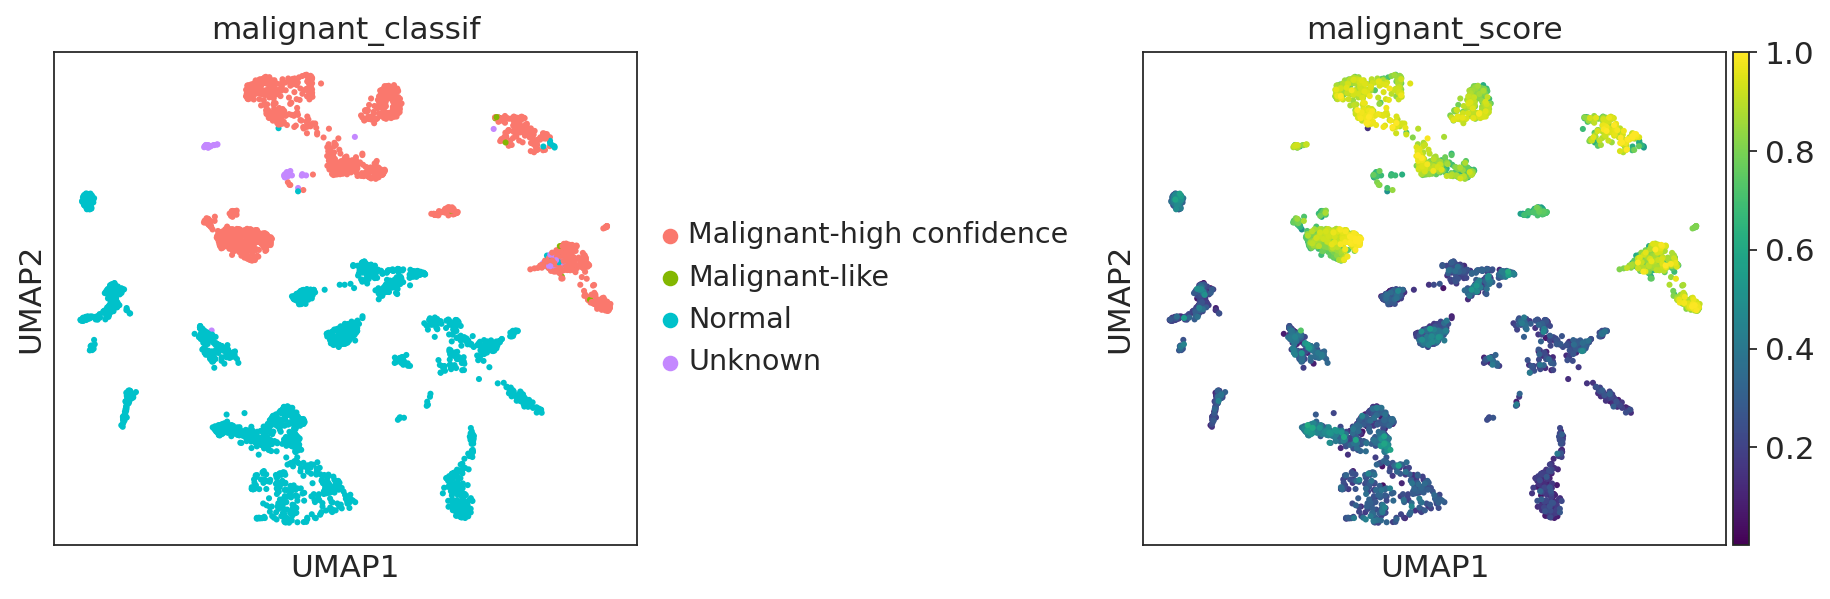

In [13]:
sc.pl.umap(adata, color=['malignant_classif', 'malignant_score'], wspace=0.7, cmap='viridis')

A summary of the malignant annotation process with the CNV heatmap is obtained with `plot_cnv_by_sample`.

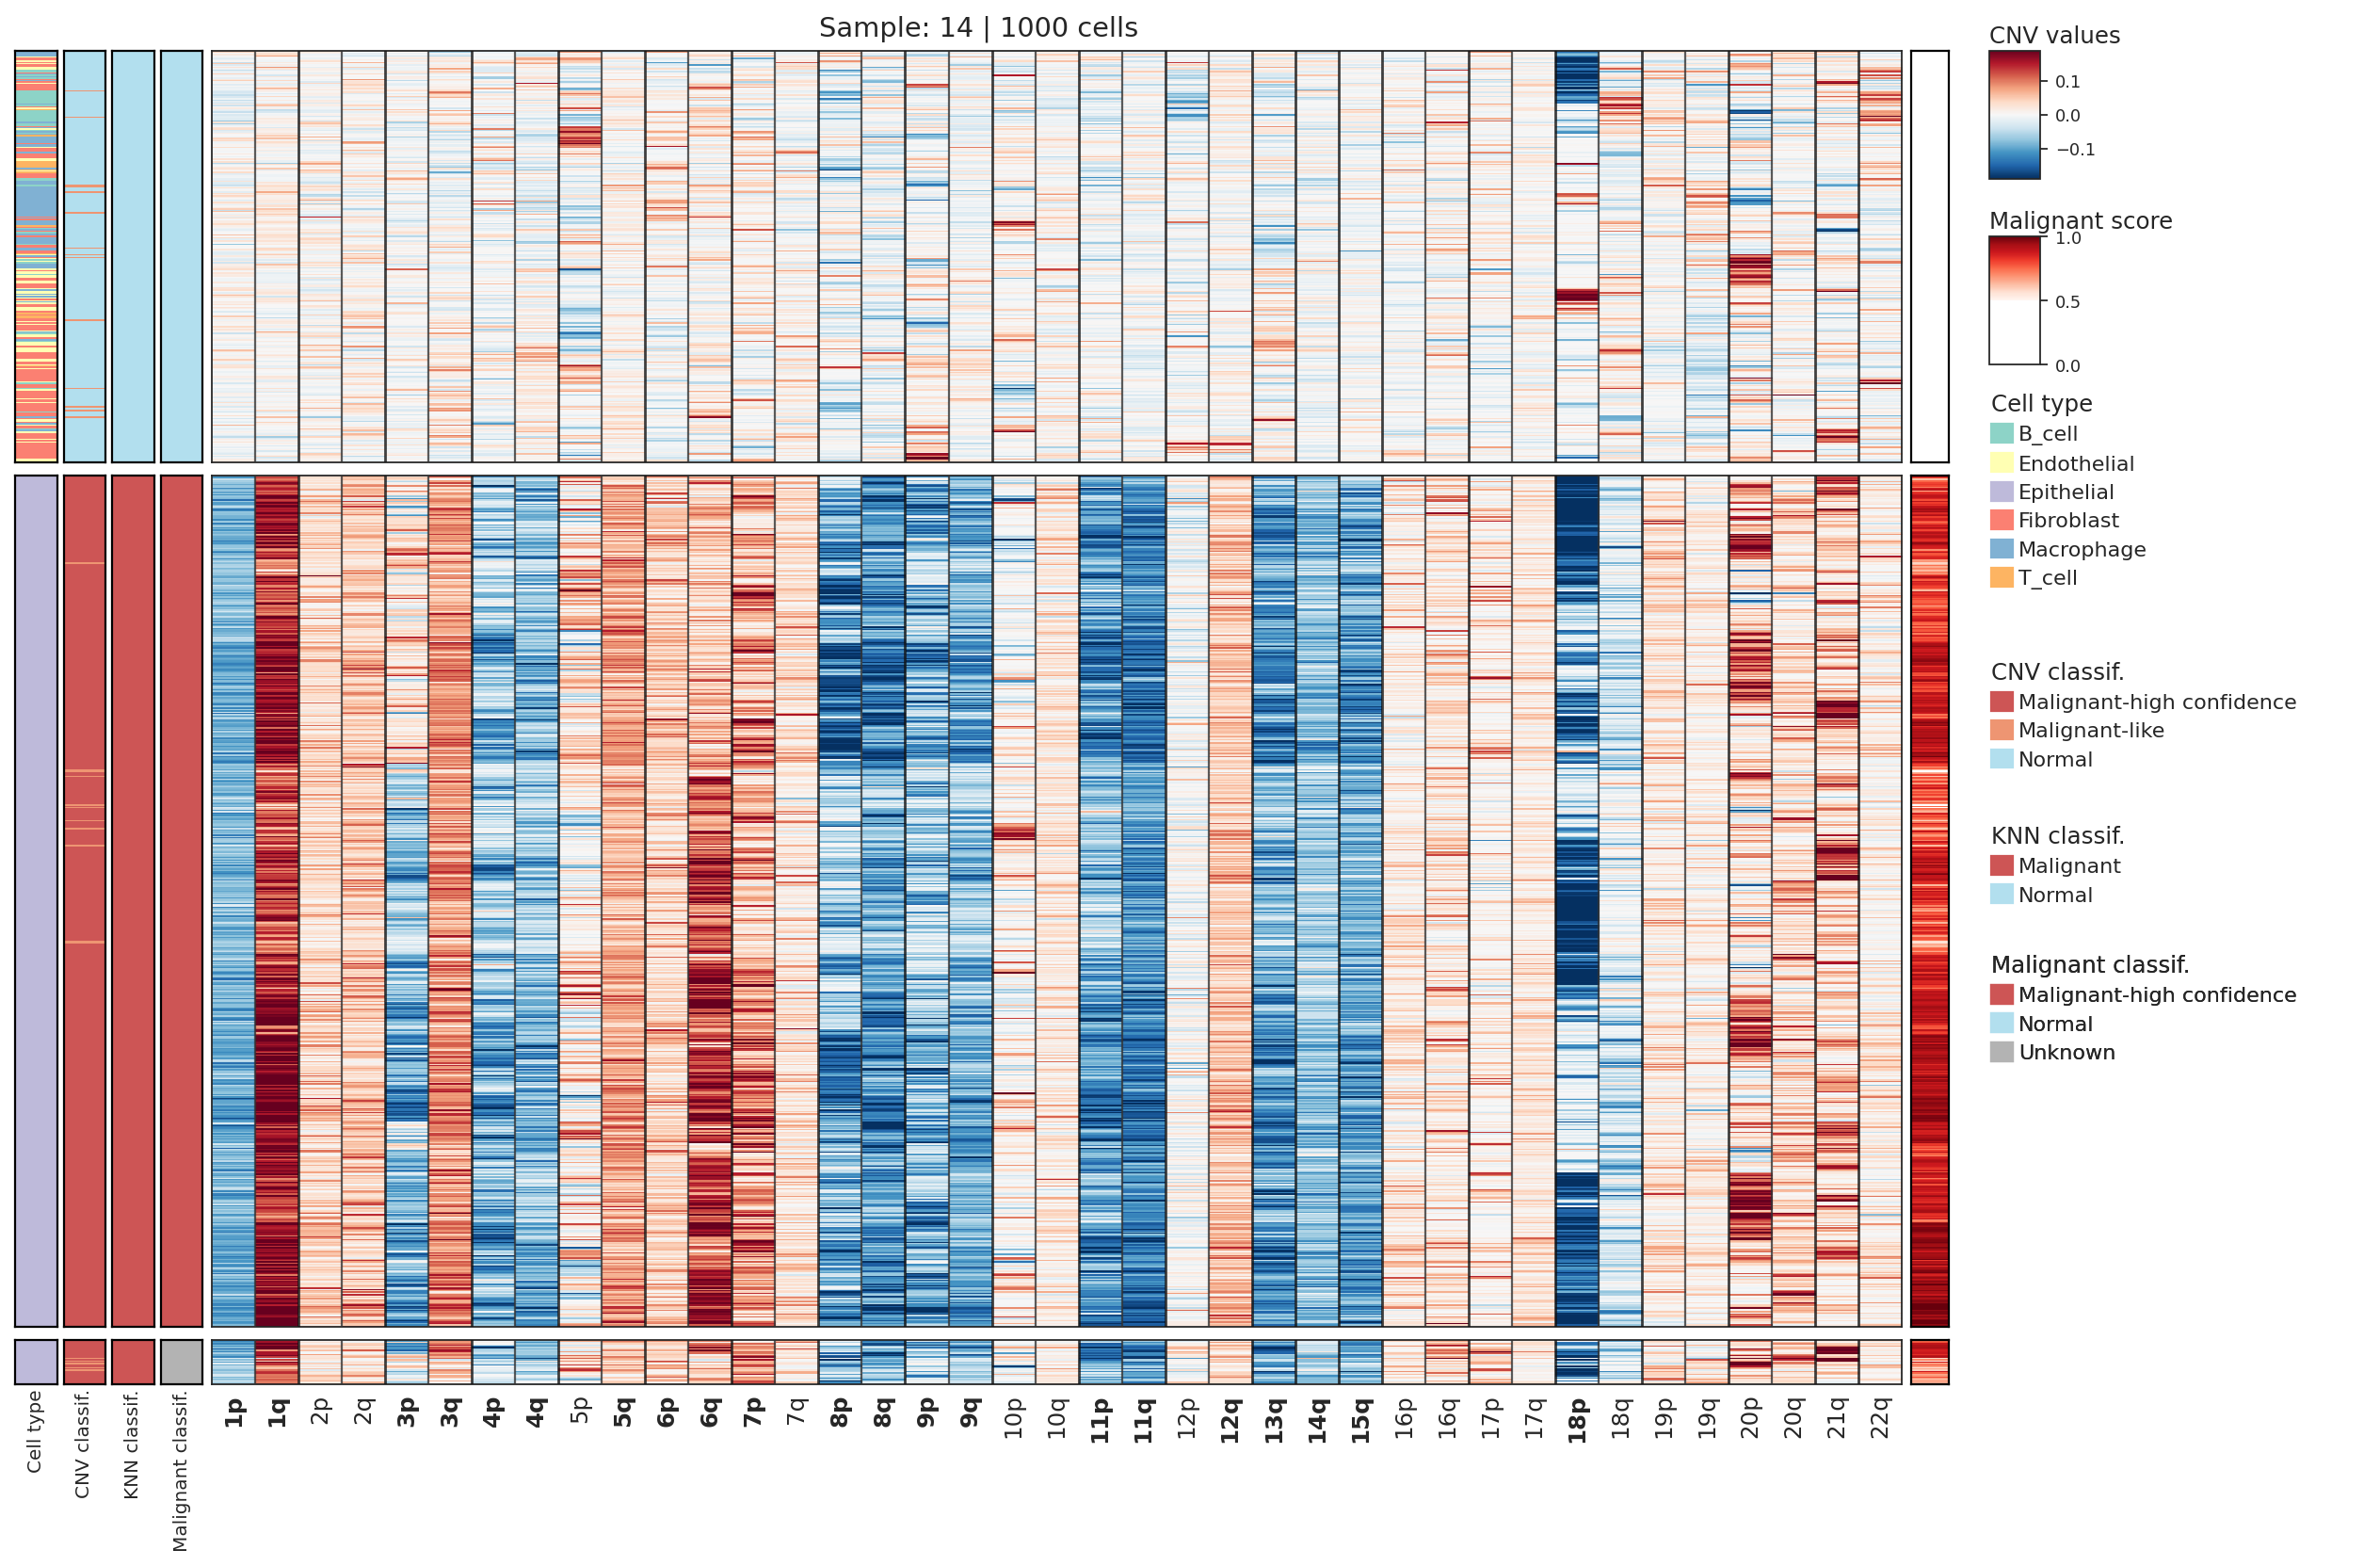

In [14]:
hotspotarms_dict = (classifier.master_hotspotarms_df.loc[classifier.master_hotspotarms_df['hotspotarm'] == 'Yes']
    .groupby('sample')['chrarms']
    .agg(lambda x: x.unique())
    .to_dict()
    )


cnv.plot_cnv_by_sample(adata, cell_type_key = 'cell_type', group_key='sample', sample_name='14',
                        highlight_arms= hotspotarms_dict)


The heatmaps for all the samples are genereted in the `CNV_heatmaps_samples.pdf` classification report.

Finally, the `plot_alluvial` function shows whihc original cell types were annotated as malignant

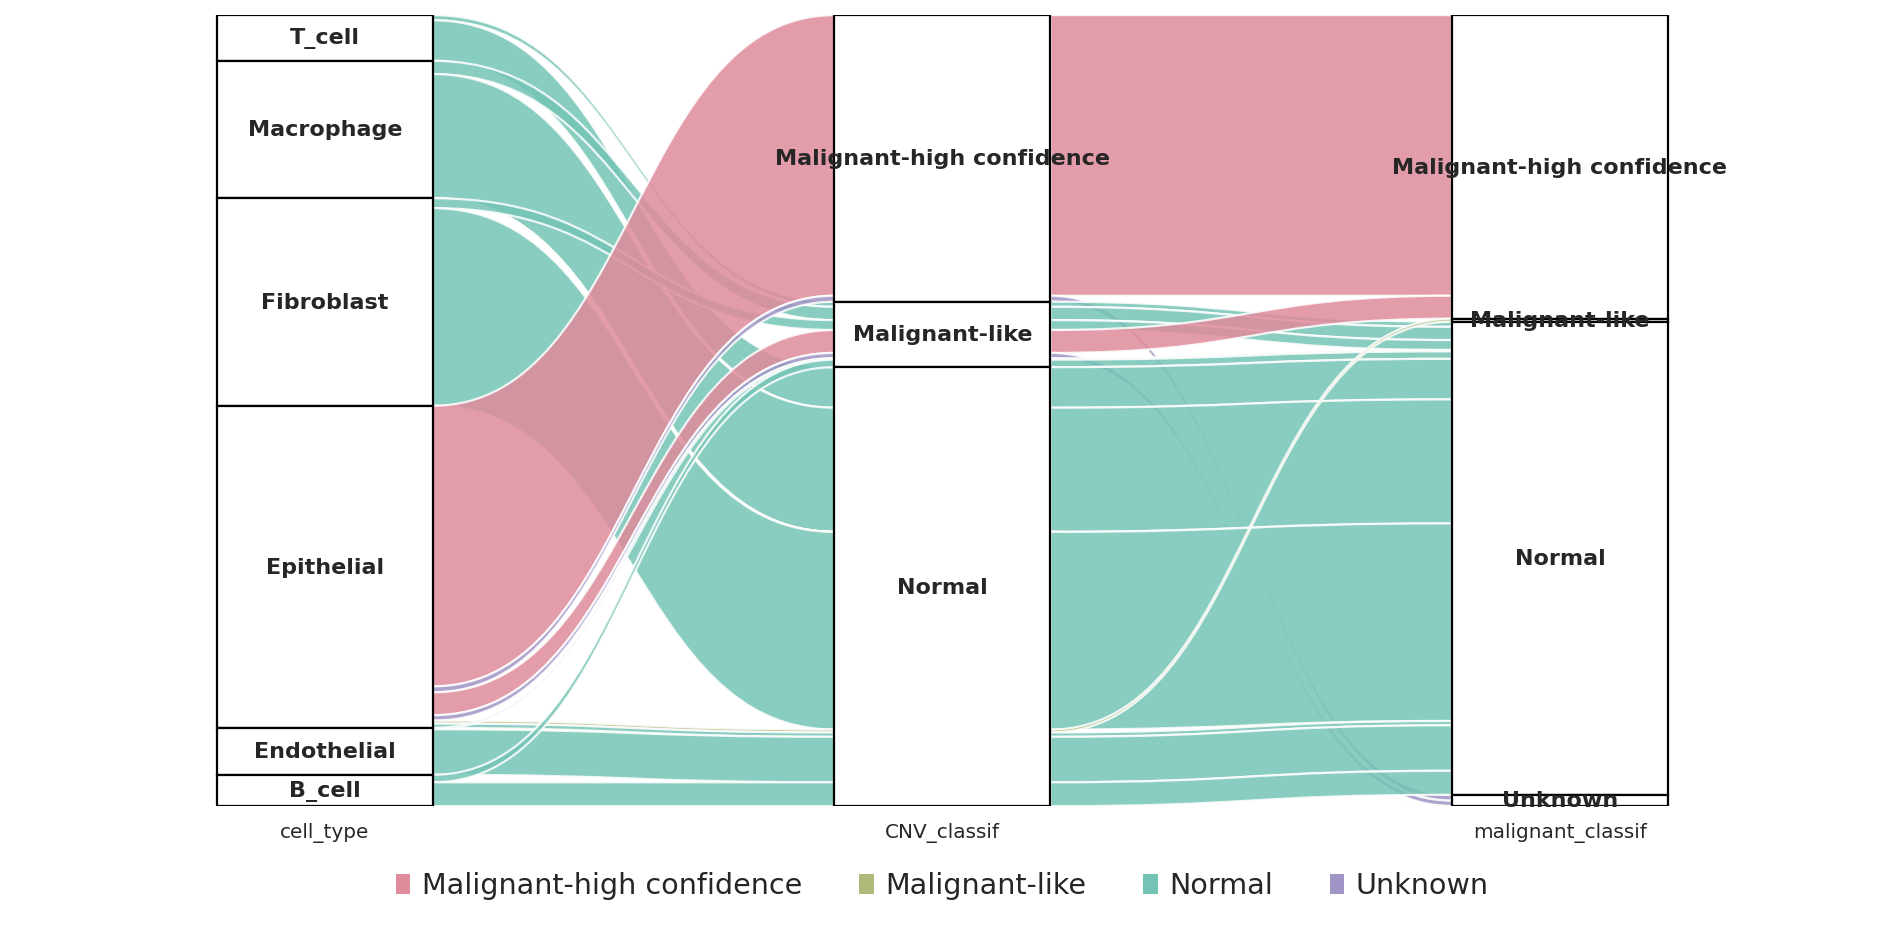

In [15]:
cnv.plot_alluvial(adata, cell_type_key='cell_type')